<a href="https://colab.research.google.com/github/AsharAli-07/AI-Powered-Emotion-Detection-and-Therapy-Wristband/blob/Data-Preprocessing-and-ML/HumanVitalSigns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving human_vital_signs_dataset_2024.csv to human_vital_signs_dataset_2024.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
df = pd.read_csv('human_vital_signs_dataset_2024.csv')
df.head()


,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient ID                200020 non-null  int64  
 1   Heart Rate                200020 non-null  int64  
 2   Respiratory Rate          200020 non-null  int64  
 3   Timestamp                 200020 non-null  object 
 4   Body Temperature          200020 non-null  float64
 5   Oxygen Saturation         200020 non-null  float64
 6   Systolic Blood Pressure   200020 non-null  int64  
 7   Diastolic Blood Pressure  200020 non-null  int64  
 8   Age                       200020 non-null  int64  
 9   Gender                    200020 non-null  object 
 10  Weight (kg)               200020 non-null  float64
 11  Height (m)                200020 non-null  float64
 12  Derived_HRV               200020 non-null  float64
 13  Derived_Pulse_Pressure    200020 non-null  i

In [5]:
df.drop('Patient ID', axis=1, inplace=True)

In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [7]:
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month


In [8]:
df.drop('Timestamp', axis=1, inplace=True)


In [9]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

In [10]:
le_risk = LabelEncoder()
df['Risk Category'] = le_risk.fit_transform(df['Risk Category'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Heart Rate                200020 non-null  int64  
 1   Respiratory Rate          200020 non-null  int64  
 2   Body Temperature          200020 non-null  float64
 3   Oxygen Saturation         200020 non-null  float64
 4   Systolic Blood Pressure   200020 non-null  int64  
 5   Diastolic Blood Pressure  200020 non-null  int64  
 6   Age                       200020 non-null  int64  
 7   Gender                    200020 non-null  int64  
 8   Weight (kg)               200020 non-null  float64
 9   Height (m)                200020 non-null  float64
 10  Derived_HRV               200020 non-null  float64
 11  Derived_Pulse_Pressure    200020 non-null  int64  
 12  Derived_BMI               200020 non-null  float64
 13  Derived_MAP               200020 non-null  f

In [12]:
X = df.drop('Risk Category', axis=1)
y = df['Risk Category']

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=12, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21023
           1       1.00      1.00      1.00     18981

    accuracy                           1.00     40004
   macro avg       1.00      1.00      1.00     40004
weighted avg       1.00      1.00      1.00     40004



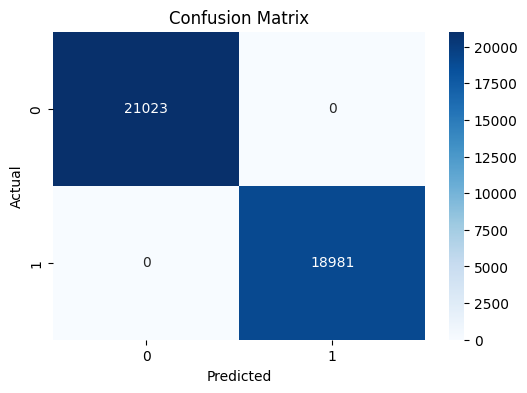

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [20]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance

,Feature,Importance
12,Derived_BMI,0.478271
0,Heart Rate,0.330096
8,Weight (kg),0.107689
9,Height (m),0.080064
3,Oxygen Saturation,0.000564
2,Body Temperature,0.000554
10,Derived_HRV,0.000519
6,Age,0.000336
11,Derived_Pulse_Pressure,0.000305
13,Derived_MAP,0.000303


In [21]:
X.columns

Index(['Heart Rate', 'Respiratory Rate', 'Body Temperature',
       'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Hour', 'Day', 'Month'],
      dtype='object')

In [29]:
def predict_mental_health(input_data):
    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data], columns=X.columns)

    # Scale input using trained scaler
    input_scaled = scaler.transform(input_df)

    # Predict risk category
    prediction = model.predict(input_scaled)

    # Decode prediction - only 2 classes here
    risk_map = {0: "Low Risk", 1: "High Risk"}

    return risk_map[prediction[0]]


In [31]:
sample_input = [
    72,     # Heart Rate (BPM)
    16,     # Respiratory Rate
    36.8,   # Body Temperature (°C)
    98,     # Oxygen Saturation (%)
    118,    # Systolic Blood Pressure
    76,     # Diastolic Blood Pressure
    22,     # Age
    1,      # Gender (1=Male, 0=Female)
    70,     # Weight (kg)
    1.75,   # Height (m)
    65,     # Derived_HRV
    42,     # Derived_Pulse_Pressure
    22.9,   # Derived_BMI
    90,     # Derived_MAP
    10,     # Hour (from Timestamp)
    15,     # Day (from Timestamp)
    6       # Month (from Timestamp)
]


In [32]:
result = predict_mental_health(sample_input)
print("Predicted Mental Health Risk:", result)


Predicted Mental Health Risk: High Risk


In [33]:
def predict_mental_health_with_proba(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = scaler.transform(input_df)

    prediction = model.predict(input_scaled)
    proba = model.predict_proba(input_scaled)

    risk_map = {0: "Low Risk", 1: "High Risk"}

    return risk_map[prediction[0]], proba[0]


In [34]:
predicted_risk, probabilities = predict_mental_health_with_proba(sample_input)
print("Predicted Risk:", predicted_risk)
print(f"Probabilities - Low Risk: {probabilities[0]:.2f}, High Risk: {probabilities[1]:.2f}")


Predicted Risk: High Risk
Probabilities - Low Risk: 0.02, High Risk: 0.98


In [36]:
# Your prediction function (corrected)
def predict_mental_health(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)
    risk_map = {0: "Low Risk", 1: "High Risk"}
    return risk_map[prediction[0]]

# Sample inputs (2 examples)
sample_inputs = [
    # Sample 1: Typical healthy person
    [
        72,     # Heart Rate
        16,     # Respiratory Rate
        36.8,   # Body Temperature
        98,     # Oxygen Saturation
        118,    # Systolic BP
        76,     # Diastolic BP
        22,     # Age
        1,      # Gender (1=Male)
        70,     # Weight (kg)
        1.75,   # Height (m)
        65,     # Derived_HRV
        42,     # Derived_Pulse_Pressure
        22.9,   # Derived_BMI
        90,     # Derived_MAP
        10,     # Hour
        15,     # Day
        6       # Month
    ],
    # Sample 2: Possible high risk case (low HRV, high HR)
    [
        110,    # Heart Rate (high)
        22,     # Respiratory Rate
        37.2,   # Body Temperature
        93,     # Oxygen Saturation
        140,    # Systolic BP (high)
        90,     # Diastolic BP
        35,     # Age
        0,      # Gender (0=Female)
        85,     # Weight (kg)
        1.65,   # Height (m)
        12,     # Derived_HRV (low)
        50,     # Derived_Pulse_Pressure
        31.2,   # Derived_BMI
        110,    # Derived_MAP
        20,     # Hour
        22,     # Day
        9       # Month
    ]
]

# Running prediction and printing results
for i, sample in enumerate(sample_inputs, 1):
    result = predict_mental_health(sample)
    print(f"Sample {i} Prediction: {result}")


Sample 1 Prediction: High Risk
Sample 2 Prediction: Low Risk


In [37]:
import joblib

joblib.dump(model, 'mental_health_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [38]:
from google.colab import files

files.download('mental_health_rf_model.pkl')
files.download('scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
import joblib
from google.colab import files

# Save model and scaler
joblib.dump(model, 'mental_health_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Confirm files exist
!ls

# Download files
files.download('mental_health_rf_model.pkl')
files.download('scaler.pkl')


human_vital_signs_dataset_2024.csv  sample_data
mental_health_rf_model.pkl	    scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>